Best-selling product:
                name  total_sold
0  Classic White Tee           9

Total sales per category:
      category  total_sales
0  Accessories         50.0
1      Apparel        450.0
2  Electronics        480.0
3      Fitness        130.0
4     Footwear        300.0
5         Home        177.0

Average purchase per customer:
  customer_name  avg_purchase
0   Arjun Verma     45.000000
1    Asha Patel     85.000000
2   Karan Desai     70.000000
3   Meera Joshi     50.000000
4      Neha Rao     75.000000
5    Priya Nair     46.666667
6  Rahul Sharma     17.333333
7  Sanjay Mehta     26.666667
8    Sneha Khan     90.000000
9  Vikram Singh     23.333333

Monthly sales trend:
     month  monthly_total
0  2025-05          342.0
1  2025-06          290.0
2  2025-07          396.0
3  2025-08          559.0


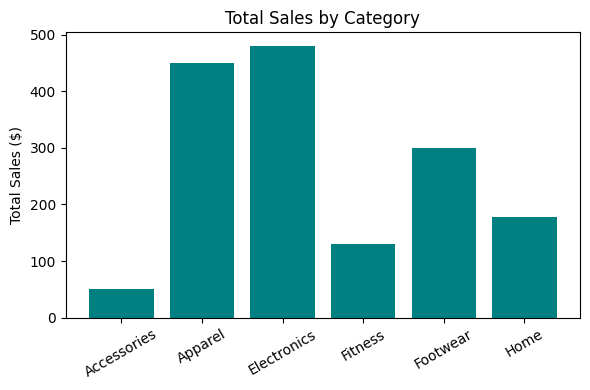

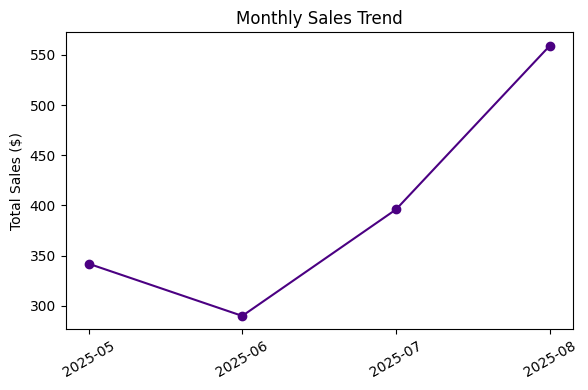

In [3]:
import sqlite3
import pandas as pd

# Connect to (and create) the database
conn = sqlite3.connect("sales.db")
cursor = conn.cursor()

# Create and populate tables
cursor.executescript("""
CREATE TABLE Products (
    product_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    category TEXT,
    price REAL
);

CREATE TABLE Customers (
    customer_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    age INTEGER,
    city TEXT
);

CREATE TABLE Sales (
    sale_id INTEGER PRIMARY KEY,
    sale_date TEXT NOT NULL,
    product_id INTEGER,
    customer_id INTEGER,
    quantity INTEGER,
    total_price REAL,
    FOREIGN KEY(product_id) REFERENCES Products(product_id),
    FOREIGN KEY(customer_id) REFERENCES Customers(customer_id)
);

INSERT INTO Products VALUES (1, 'Classic White Tee', 'Apparel', 15.0);
INSERT INTO Products VALUES (2, 'Blue Jeans', 'Apparel', 45.0);
INSERT INTO Products VALUES (3, 'Running Shoes', 'Footwear', 75.0);
INSERT INTO Products VALUES (4, 'Leather Belt', 'Accessories', 25.0);
INSERT INTO Products VALUES (5, 'Coffee Mug', 'Home', 12.0);
INSERT INTO Products VALUES (6, 'LED Desk Lamp', 'Home', 35.0);
INSERT INTO Products VALUES (7, 'Noise-Cancelling Headphones', 'Electronics', 120.0);
INSERT INTO Products VALUES (8, 'Wireless Mouse', 'Electronics', 30.0);
INSERT INTO Products VALUES (9, 'Yoga Mat', 'Fitness', 20.0);
INSERT INTO Products VALUES (10, 'Water Bottle', 'Fitness', 10.0);

INSERT INTO Customers VALUES (1, 'Asha', 'Patel', 28, 'Mumbai');
INSERT INTO Customers VALUES (2, 'Rahul', 'Sharma', 34, 'Delhi');
INSERT INTO Customers VALUES (3, 'Priya', 'Nair', 22, 'Bengaluru');
INSERT INTO Customers VALUES (4, 'Vikram', 'Singh', 45, 'Pune');
INSERT INTO Customers VALUES (5, 'Sneha', 'Khan', 31, 'Hyderabad');
INSERT INTO Customers VALUES (6, 'Karan', 'Desai', 38, 'Chennai');
INSERT INTO Customers VALUES (7, 'Neha', 'Rao', 27, 'Kolkata');
INSERT INTO Customers VALUES (8, 'Sanjay', 'Mehta', 50, 'Surat');
INSERT INTO Customers VALUES (9, 'Meera', 'Joshi', 41, 'Ahmedabad');
INSERT INTO Customers VALUES (10, 'Arjun', 'Verma', 19, 'Jaipur');

INSERT INTO Sales VALUES (1, '2025-05-02', 1, 1, 2, 30.0);
INSERT INTO Sales VALUES (2, '2025-05-03', 5, 2, 1, 12.0);
INSERT INTO Sales VALUES (3, '2025-05-05', 3, 3, 1, 75.0);
INSERT INTO Sales VALUES (4, '2025-05-05', 2, 4, 1, 45.0);
INSERT INTO Sales VALUES (5, '2025-05-10', 7, 5, 1, 120.0);
INSERT INTO Sales VALUES (6, '2025-05-12', 8, 6, 2, 60.0);
INSERT INTO Sales VALUES (7, '2025-06-01', 1, 7, 3, 45.0);
INSERT INTO Sales VALUES (8, '2025-06-03', 9, 8, 1, 20.0);
INSERT INTO Sales VALUES (9, '2025-06-07', 2, 9, 2, 90.0);
INSERT INTO Sales VALUES (10, '2025-06-09', 6, 10, 1, 35.0);
INSERT INTO Sales VALUES (11, '2025-06-15', 3, 1, 1, 75.0);
INSERT INTO Sales VALUES (12, '2025-06-20', 4, 2, 1, 25.0);
INSERT INTO Sales VALUES (13, '2025-07-02', 10, 3, 4, 40.0);
INSERT INTO Sales VALUES (14, '2025-07-05', 1, 4, 1, 15.0);
INSERT INTO Sales VALUES (15, '2025-07-07', 7, 5, 1, 120.0);
INSERT INTO Sales VALUES (16, '2025-07-10', 8, 6, 1, 30.0);
INSERT INTO Sales VALUES (17, '2025-07-12', 2, 7, 1, 45.0);
INSERT INTO Sales VALUES (18, '2025-07-15', 5, 8, 3, 36.0);
INSERT INTO Sales VALUES (19, '2025-07-20', 9, 9, 2, 40.0);
INSERT INTO Sales VALUES (20, '2025-07-25', 6, 10, 2, 70.0);
INSERT INTO Sales VALUES (21, '2025-08-01', 3, 1, 2, 150.0);
INSERT INTO Sales VALUES (22, '2025-08-03', 1, 2, 1, 15.0);
INSERT INTO Sales VALUES (23, '2025-08-05', 4, 3, 1, 25.0);
INSERT INTO Sales VALUES (24, '2025-08-09', 10, 4, 1, 10.0);
INSERT INTO Sales VALUES (25, '2025-08-10', 8, 5, 1, 30.0);
INSERT INTO Sales VALUES (26, '2025-08-15', 7, 6, 1, 120.0);
INSERT INTO Sales VALUES (27, '2025-08-18', 2, 7, 3, 135.0);
INSERT INTO Sales VALUES (28, '2025-08-20', 5, 8, 2, 24.0);
INSERT INTO Sales VALUES (29, '2025-08-22', 9, 9, 1, 20.0);
INSERT INTO Sales VALUES (30, '2025-08-25', 1, 10, 2, 30.0);
""")
conn.commit()

# ---- Query 1: Best-selling product ----
best_seller = pd.read_sql_query("""
SELECT Products.name, SUM(Sales.quantity) AS total_sold
FROM Sales
JOIN Products ON Sales.product_id = Products.product_id
GROUP BY Products.name
ORDER BY total_sold DESC
LIMIT 1;
""", conn)
print("Best-selling product:")
print(best_seller)

# ---- Query 2: Total sales per category ----
category_sales = pd.read_sql_query("""
SELECT Products.category, SUM(Sales.total_price) AS total_sales
FROM Sales
JOIN Products ON Sales.product_id = Products.product_id
GROUP BY Products.category;
""", conn)
print("\nTotal sales per category:")
print(category_sales)

# ---- Query 3: Average purchase per customer ----
avg_purchase = pd.read_sql_query("""
SELECT Customers.first_name || ' ' || Customers.last_name AS customer_name,
       AVG(Sales.total_price) AS avg_purchase
FROM Sales
JOIN Customers ON Sales.customer_id = Customers.customer_id
GROUP BY customer_name;
""", conn)
print("\nAverage purchase per customer:")
print(avg_purchase)

# ---- Query 4: Monthly sales trend ----
monthly_trend = pd.read_sql_query("""
SELECT strftime('%Y-%m', sale_date) AS month, SUM(total_price) AS monthly_total
FROM Sales
GROUP BY month
ORDER BY month;
""", conn)
print("\nMonthly sales trend:")
print(monthly_trend)

# ---- Visualizations ----
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(category_sales['category'], category_sales['total_sales'], color='teal')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(monthly_trend['month'], monthly_trend['monthly_total'], marker='o', color='indigo')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()